In [1]:
import pandas as pd
import numpy as np
import pm4py
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Here insert the custom packages

In [2]:
sns.set_theme(style='darkgrid')
warnings.filterwarnings('ignore')

In [3]:
FILE_PATH = 'data/dispatch_data.csv'
df_complete = pd.read_csv(FILE_PATH)
df_complete['timestamp'] = pd.to_datetime(df_complete['timestamp'])
df_complete = df_complete.rename(columns={'case_id': 'cycle_iteration'})
df_complete = df_complete.drop(columns=['shiftname.1'])

In [4]:
# Processing to obtain the truck as the case_id
df_complete = df_complete.rename(columns={'truck': 'case_id'})
minimum_column = ['case_id', 'activity', 'timestamp']
remaining_cols = set(df_complete.columns) - set(minimum_column)
df_complete = df_complete[[*minimum_column, *remaining_cols]]
df_complete = df_complete.sort_values(by=['case_id', 'timestamp'])
df_complete.head(3)

,case_id,activity,timestamp,shiftname,loadlocationunit,resource,crew,excav,dumplocation,loadlocation,cycle_iteration,dumplocationunit
310401,CA100,Assign Carga,2024-02-25 21:51:12.200,240226a,Disparo,Felipe Villablanca Cortes,G4,PA,BOT-RAMP-3680,F11,43252,Botadero
310402,CA100,Arrive Carga,2024-02-25 22:01:15.000,240226a,Disparo,Felipe Villablanca Cortes,G4,PA,BOT-RAMP-3680,F11,43252,Botadero
310403,CA100,Spotting Carga,2024-02-25 22:01:15.000,240226a,Disparo,Felipe Villablanca Cortes,G4,PA,BOT-RAMP-3680,F11,43252,Botadero


In [5]:
df_diff = df_complete.copy()
df_diff['delta_time'] = df_complete[['case_id', 'timestamp']].groupby('case_id').diff()['timestamp'].dt.total_seconds() / 60 # Minutes

In [6]:
percentile_above_one_hour = 98.8296
# np.percentile(df_diff['delta_time'].dropna(), percentile_above_one_hour)
percentage_above_one_hour = 1 - percentile_above_one_hour
print(f'The amount of transitions above one hour is {percentage_above_one_hour}')


The amount of transitions above one hour is -97.8296


In [7]:
# Measure everything in minutes
DELTA_TIME_THRESHOLD = 60 # 1 hour
total_transitions = df_diff.shape[0]
print(f'Total transitions: {total_transitions}')
df_threshtimes = df_diff[df_diff['delta_time'] > DELTA_TIME_THRESHOLD]
print(f'Total delayed transitions {df_threshtimes.shape[0]}')

Total transitions: 368307
Total delayed transitions 4311


In [8]:
# Top trucks that acumulated the delayed transitions
df_summary_by_truck = df_threshtimes.groupby('case_id')[['delta_time']].agg(['mean', 'max', 'count']).reset_index()
df_summary_by_truck.columns = ['case_id', 'mean', 'max', 'count']

total_trucks = df_summary_by_truck['case_id'].nunique() # Should be 54
display(df_summary_by_truck.sort_values('count', ascending=False).head(5))
total_idle_time = (df_summary_by_truck['count'] * df_summary_by_truck['mean']).div(60).sum()
print(f'Mean times that trucks are delayed    : {df_summary_by_truck['count'].mean():.1f} times')
print(f'Mean time delayed trucks in each time : {df_summary_by_truck['mean'].mean():.1f} minutes')
print(f'Total time idle                       : {total_idle_time:.2f} hours')

hours_stopped_per_year_by_maintenance_per_truck = 667 # hours: ChatGPT estimated
hours_stopped_per_month_by_maintenance = hours_stopped_per_year_by_maintenance_per_truck / 12 * total_trucks
total_loss_time = total_idle_time - hours_stopped_per_month_by_maintenance
print(f'Time per month in maintenance         : {(hours_stopped_per_month_by_maintenance):.2f} hours')
print(f'Time loss                             : {total_loss_time:.1f} hours')

,case_id,mean,max,count
2,CA102,116.478561,573.850000,95
28,CA73,117.886523,2255.470000,93
26,CA70,124.482975,979.136667,93
52,CA98,105.852826,653.136667,92
39,CA85,133.379674,1159.353333,92


Mean times that trucks are delayed    : 79.8 times
Mean time delayed trucks in each time : 167.6 minutes
Total time idle                       : 11756.77 hours
Time per month in maintenance         : 3001.50 hours
Time loss                             : 8755.3 hours


In [9]:
print('Total trucks:                             ', df_diff['case_id'].nunique())
print('Trucks with more than one hour detention: ', df_threshtimes['case_id'].nunique())

Total trucks:                              54
Trucks with more than one hour detention:  54


Mean time lost by truck 13063.1 minutes
Mean time lost by truck 217.7 hours


,case_id,delta_time,hour_lost
8,CA108,29487.273333,491.454556
19,CA63,20868.020000,347.800333
11,CA52,19992.033333,333.200556
12,CA55,19841.843333,330.697389
43,CA89,19170.030000,319.500500


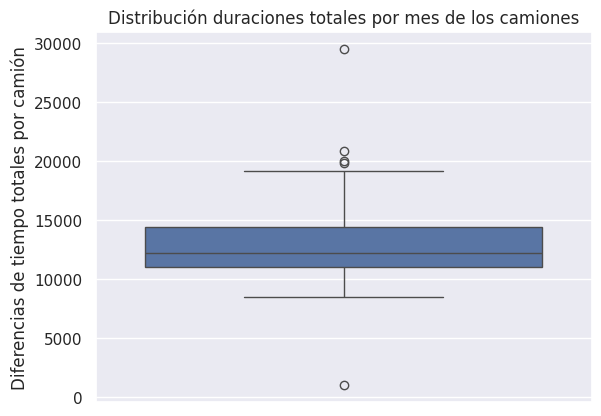

In [10]:
ax = sns.boxplot(df_threshtimes[['case_id', 'delta_time']].groupby('case_id').sum())
ax.set(title='Distribución duraciones totales por mes de los camiones', ylabel='Diferencias de tiempo totales por camión', xlabel=None);
df_mean_time_lost = df_threshtimes[['case_id', 'delta_time']].groupby('case_id').sum()['delta_time'].reset_index()
plt.xticks([0], [''])
print(f'Mean time lost by truck {(df_mean_time_lost['delta_time'].mean()):.1f} minutes')
print(f'Mean time lost by truck {(df_mean_time_lost['delta_time'].mean() / 60):.1f} hours')
df_mean_time_lost['hour_lost'] = df_mean_time_lost['delta_time'].div(60)
df_mean_time_lost.sort_values(by='hour_lost', ascending=False).head()


In [11]:
df_count = df_threshtimes[['case_id', 'activity']].groupby(['case_id', 'activity'])['activity'].count()
df_count.name = 'frequency'
df_count = df_count.reset_index().sort_values('frequency', ascending=False)
display(df_count.head(10))
display(df_count.groupby('activity')['frequency'].sum().reset_index())

,case_id,activity,frequency
85,CA70,Assign Carga,53
72,CA66,Assign Carga,51
92,CA73,Assign Carga,50
127,CA85,Assign Carga,50
170,CA98,Assign Carga,48
157,CA94,Assign Carga,48
16,CA104,Assign Carga,48
114,CA81,Assign Carga,48
120,CA83,Assign Carga,47
105,CA78,Assign Carga,47


,activity,frequency
0,Arrive Carga,1816
1,Arrive Descarga,226
2,Assign Carga,2256
3,Empty Descarga,8
4,Spotting Carga,5


In [12]:
df_time_diff = df_threshtimes[['activity', 'delta_time']].groupby('activity').mean().reset_index()
df_time_diff

,activity,delta_time
0,Arrive Carga,105.576120
1,Arrive Descarga,95.090192
2,Assign Carga,217.278865
3,Empty Descarga,203.343750
4,Spotting Carga,76.346667


In [13]:
df_activity_frequency = df_count.groupby(by='activity')['frequency'].agg(['sum', 'count']).reset_index()
df_activity_frequency

,activity,sum,count
0,Arrive Carga,1816,54
1,Arrive Descarga,226,54
2,Assign Carga,2256,54
3,Empty Descarga,8,7
4,Spotting Carga,5,5


In [14]:
df_time_diff.merge(df_activity_frequency, on='activity')

,activity,delta_time,sum,count
0,Arrive Carga,105.576120,1816,54
1,Arrive Descarga,95.090192,226,54
2,Assign Carga,217.278865,2256,54
3,Empty Descarga,203.343750,8,7
4,Spotting Carga,76.346667,5,5


In [15]:
df_complete['timestamp'].agg(['min', 'max']).to_frame()

,timestamp
min,2024-02-25 11:07:29.200
max,2024-03-26 08:46:07.000
